In [1]:
from langgraph.graph import StateGraph, START, END
from  langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Literal
load_dotenv()

/Users/rahultiwari/Documents/02_Freelancing/Hachion_batch/ai_engineering_19th_may/ai-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
# state definations
class SentimentState(TypedDict):
    original_tweet: str
    sentiment: str
    confidence: float
    response_tweet: str

In [ ]:
class SentimentAnalysis(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment classification either positive or negative")
    confidence: float = Field(ge=0, le=1.0, description="Confidence score from 0.0 to 1.0")
    reason: str = Field(description="Brief explanation")

In [9]:
# node 1
def analyze_sentiment(state: SentimentState):
    tweet = state["original_tweet"]
    messages = [
        SystemMessage("Analyze sentiment and provide the structured output. Use 0 to 1.0 scale for confidence. lower is negative and higher is positive"),
        HumanMessage(tweet)
    ]

    structured_llm = llm.with_structured_output(SentimentAnalysis)
    analysis = structured_llm.invoke(messages)
    return {'sentiment': analysis.sentiment,
            'confidence': analysis.confidence}


def generate_postive_response(state: SentimentState):
    
    print(f"current state in positive respone node: {state}")

    messages = [
        SystemMessage(f"""Generate a warm response to this positive tweet under 280 chars.
                      Confidence: {state['confidence']}. High confidence means be enthusiastic otherwise be friendly."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}


def generate_negative_response(state: SentimentState):
    print(f"current state in negative respone node: {state}")

    messages = [
        SystemMessage(f"""Generate and empathetic response to this negative tweet under 280 chars.
                      If Confidence {state['confidence']} is very low then be empathetic otherwise 
                      be understanding."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}



In [10]:
def route_by_sentiment(state: SentimentState):
    if state['sentiment'] == 'positive':
        return "positive_response"
    
    else:
        return "negative_response"

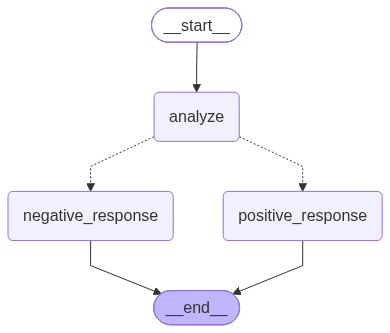

In [12]:
builder = StateGraph(SentimentState)
builder.add_node("analyze", analyze_sentiment)
builder.add_node("positive_response", generate_postive_response)
builder.add_node("negative_response", generate_negative_response)

# edges
builder.add_edge(START, "analyze")
builder.add_conditional_edges("analyze", route_by_sentiment, ["positive_response", "negative_response"])
builder.add_edge("positive_response", END)
builder.add_edge("negative_response", END)
graph = builder.compile()
graph


In [15]:
tweet = "Just launched my new product! the response is very bad."

result = graph.invoke({'original_tweet': tweet})

current state in negative respone node: {'original_tweet': 'Just launched my new product! the response is very bad.', 'sentiment': 'negative', 'confidence': 0.85}


In [16]:
result

{'original_tweet': 'Just launched my new product! the response is very bad.',
 'sentiment': 'negative',
 'confidence': 0.85,
 'response_tweet': "I’m really sorry to hear that the response hasn’t met your expectations. Launching something new is a huge step, and it can be tough when things don't go as planned. Remember, every experience is a learning opportunity. Your hard work will pay off! Keep pushing forward! 💪✨"}